<a href="https://colab.research.google.com/github/NguyenLenam317/08/blob/main/DeepCheX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ENVIRONMENT SETUP AND PROJECT CONFIGURATION


In [ ]:
print("--- [1/7] Setting up the environment ---")

# Core libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2

# Libraries for model building and training
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetV2B3
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import roc_auc_score

# Mount Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted successfully.")
except ImportError:
    print("Not running on Google Colab. Skipping Drive mount.")

# --- Project Configuration: Paths and Parameters ---
DRIVE_BASE_PATH = '/content/drive/MyDrive/ChestXrayData/'
CSV_LABELS_PATH = os.path.join(DRIVE_BASE_PATH, 'Data_Entry_2017.csv')
IMAGE_FOLDER_PATH = os.path.join(DRIVE_BASE_PATH, 'images-224/images-224/')
BEST_MODEL_PATH = os.path.join(DRIVE_BASE_PATH, 'best_efficientnet_model.h5')

# Target pathologies
TARGET_LABELS = ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Pneumonia', 'Pneumothorax', 'Nodule']
NUM_CLASSES = len(TARGET_LABELS)

# Model and training hyperparameters
IMG_SIZE = (224, 224) # Change to (300, 300) for larger images
BATCH_SIZE = 32

print("\n--- Project configuration complete. ---")


--- [1/7] Setting up the environment ---
Mounted at /content/drive
Google Drive mounted successfully.

--- Project configuration complete. ---


EXPLORATORY DATA ANALYSIS


--- [2/7] Starting Exploratory Data Analysis ---

[Analysis 1] Class Imbalance:


/tmp/ipython-input-537757515.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.values, y=label_counts.index, palette="viridis")


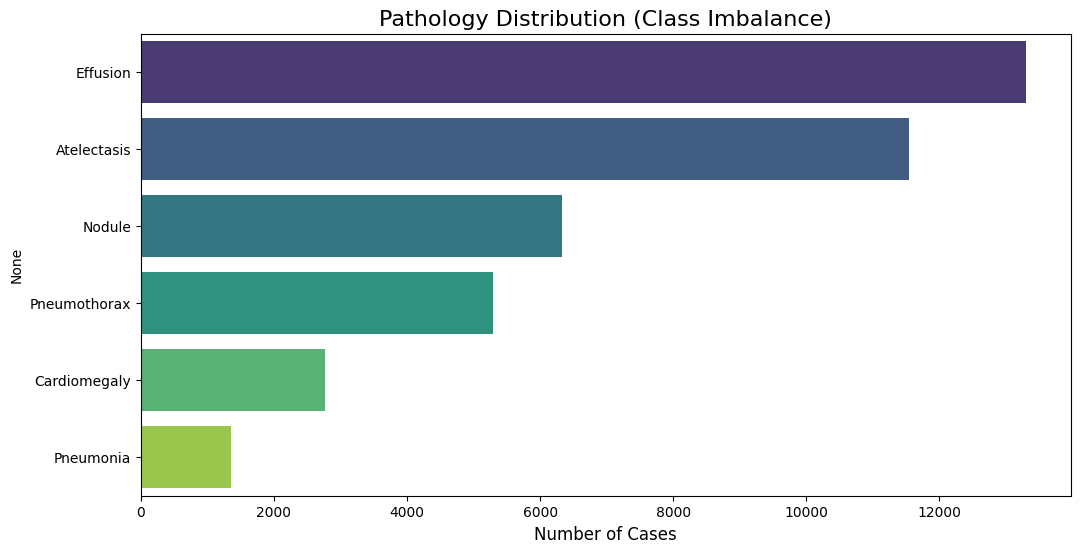

=> Insight: Severe class imbalance observed (e.g., Effusion >> Pneumonia). A Weighted Loss strategy is necessary.

[Analysis 2] Multi-Morbidity:


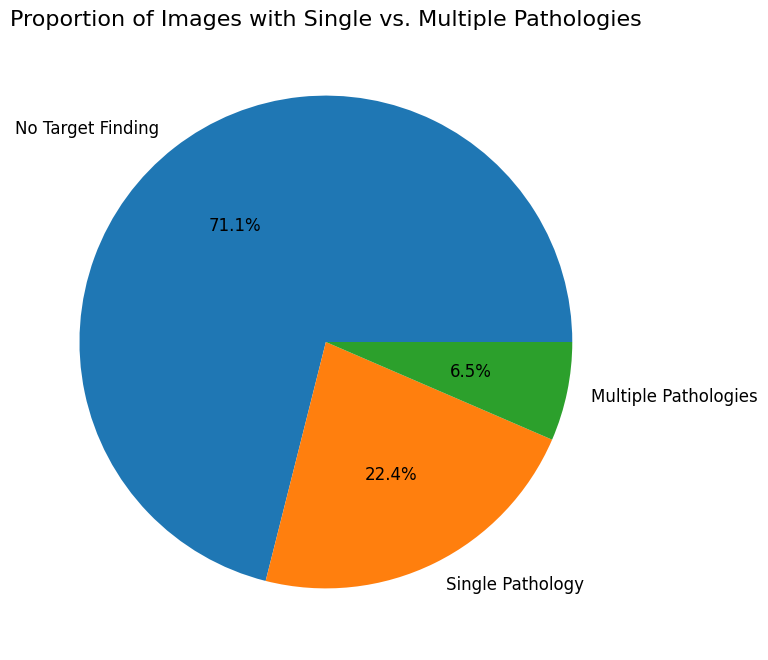

=> Insight: 6.5% of cases involve multiple diseases, requiring a multi-label classification model.

[Analysis 3] Pathology Co-occurrence:


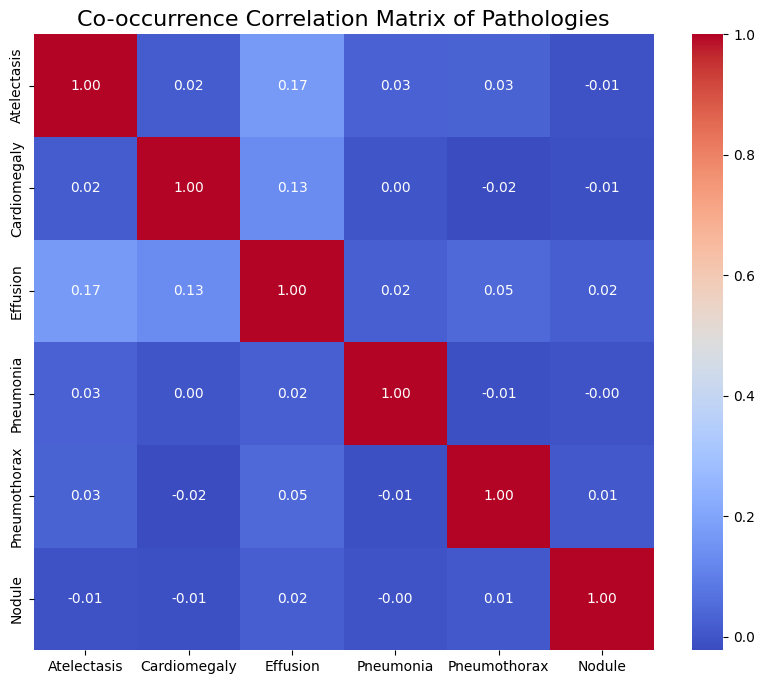

=> Insight: Correlations exist between pathologies (e.g., Effusion & Atelectasis), indicating the model must learn complex patterns.


In [ ]:

print("\n--- [2/7] Starting Exploratory Data Analysis ---")

# Load data specifically for EDA
df_eda = pd.read_csv(CSV_LABELS_PATH)
for label in TARGET_LABELS:
    df_eda[label] = df_eda['Finding Labels'].apply(lambda x: 1 if label in x else 0)

# --- 2.1 Class Imbalance Analysis ---
print("\n[Analysis 1] Class Imbalance:")
label_counts = df_eda[TARGET_LABELS].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=label_counts.values, y=label_counts.index, palette="viridis")
plt.title('Pathology Distribution (Class Imbalance)', fontsize=16)
plt.xlabel('Number of Cases', fontsize=12)
plt.show()
print("=> Insight: Severe class imbalance observed (e.g., Effusion >> Pneumonia). A Weighted Loss strategy is necessary.")

# --- 2.2 Multi-Morbidity Analysis ---
print("\n[Analysis 2] Multi-Morbidity:")
df_eda['Num_Diseases'] = df_eda[TARGET_LABELS].sum(axis=1)
def categorize_morbidity(n):
    if n == 0: return 'No Target Finding'
    elif n == 1: return 'Single Pathology'
    else: return 'Multiple Pathologies'
df_eda['Morbidity_Category'] = df_eda['Num_Diseases'].apply(categorize_morbidity)
morbidity_counts = df_eda['Morbidity_Category'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(morbidity_counts, labels=morbidity_counts.index, autopct='%1.1f%%', textprops={'fontsize': 12})
plt.title('Proportion of Images with Single vs. Multiple Pathologies', fontsize=16)
plt.show()
print(f"=> Insight: {morbidity_counts.get('Multiple Pathologies', 0) / len(df_eda) * 100:.1f}% of cases involve multiple diseases, requiring a multi-label classification model.")

# --- 2.3 Co-occurrence Analysis ---
print("\n[Analysis 3] Pathology Co-occurrence:")
correlation_matrix = df_eda[TARGET_LABELS].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Co-occurrence Correlation Matrix of Pathologies', fontsize=16)
plt.show()
print("=> Insight: Correlations exist between pathologies (e.g., Effusion & Atelectasis), indicating the model must learn complex patterns.")

# Clean up memory
del df_eda


DATA PIPELINE CONSTRUCTION


In [ ]:
print("\n--- [3/7] Building Data Pipeline ---")

# Load the main dataframe
all_labels_df = pd.read_csv(CSV_LABELS_PATH)
for label in TARGET_LABELS:
    all_labels_df[label] = all_labels_df['Finding Labels'].apply(lambda x: 1 if label in x else 0)
all_labels_df['full_path'] = all_labels_df['Image Index'].apply(lambda img: os.path.join(IMAGE_FOLDER_PATH, img))

# Split data according to the official NIH lists
train_val_list = pd.read_csv(os.path.join(DRIVE_BASE_PATH, 'train_val_list_NIH.txt'), header=None)[0].tolist()
test_list = pd.read_csv(os.path.join(DRIVE_BASE_PATH, 'test_list_NIH.txt'), header=None)[0].tolist()
train_val_df = all_labels_df[all_labels_df['Image Index'].isin(train_val_list)]
test_df = all_labels_df[all_labels_df['Image Index'].isin(test_list)]
train_df, val_df = train_test_split(train_val_df, test_size=0.1, random_state=42)
print(f"Data split complete: {len(train_df)} train, {len(val_df)} validation, {len(test_df)} test samples.")

# Configure data generators with augmentation for the training set
train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=True, zoom_range=0.1, rotation_range=5)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create the generator objects
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df, x_col='full_path', y_col=TARGET_LABELS, target_size=IMG_SIZE,
    color_mode='rgb', class_mode='raw', batch_size=BATCH_SIZE, shuffle=True
)
val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df, x_col='full_path', y_col=TARGET_LABELS, target_size=IMG_SIZE,
    color_mode='rgb', class_mode='raw', batch_size=BATCH_SIZE, shuffle=False
)
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df, x_col='full_path', y_col=TARGET_LABELS, target_size=IMG_SIZE,
    color_mode='rgb', class_mode='raw', batch_size=BATCH_SIZE, shuffle=False
)

print("\n--- Data pipeline is ready. ---")


MODEL ARCHITECTURE & TRAINING

In [ ]:
print("\n--- [4/7] Preparing for Model Training ---")

# --- 4.1 Calculate Weights for the Custom Loss Function ---
total_samples = len(train_df)
pos_weights = {}
for label in TARGET_LABELS:
    pos_count = train_df[label].sum()
    neg_count = total_samples - pos_count
    pos_weights[label] = neg_count / pos_count if pos_count > 0 else 1.0
weights = tf.constant([pos_weights[label] for label in TARGET_LABELS], dtype=tf.float32)
print("Calculated weights for Weighted Loss:", {k: round(v, 2) for k, v in pos_weights.items()})

# --- 4.2 Define the Custom Weighted Loss Function ---
def weighted_binary_crossentropy(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    weight_vector = y_true * weights + (1. - y_true)
    weighted_bce = weight_vector * bce
    return tf.reduce_mean(weighted_bce)

# --- 4.3 Build the Model Architecture ---
base_model = EfficientNetV2B3(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
predictions = Dense(NUM_CLASSES, activation='sigmoid', name='predictions')(x)
model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss=weighted_binary_crossentropy,
              metrics=[tf.keras.metrics.AUC(name='auc', multi_label=True)])
print("\n--- Model has been built and compiled. ---")

# --- 4.4 Configure Callbacks and Run Training (COMMENTED OUT) ---
# callbacks = [
#     ModelCheckpoint(BEST_MODEL_PATH, monitor='val_auc', mode='max', save_best_only=True, verbose=1),
#     EarlyStopping(monitor='val_auc', mode='max', patience=5, verbose=1, restore_best_weights=True),
#     ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.2, patience=2, verbose=1)
# ]

# print("\nSTARTING MODEL TRAINING...")
# history = model.fit(
#     train_generator,
#     epochs=20, # Number of epochs
#     validation_data=val_generator,
#     callbacks=callbacks
# )
print("\nTraining code block is commented out. Uncomment to run.")


MODEL PERFORMANCE EVALUATION

In [ ]:
print("\n--- [5/7] Evaluating Model Performance ---")

if os.path.exists(BEST_MODEL_PATH):
    print(f"Loading best model from: {BEST_MODEL_PATH}")
    # Load the model with the custom loss function
    model = load_model(BEST_MODEL_PATH, custom_objects={'weighted_binary_crossentropy': weighted_binary_crossentropy})

    print("\nEvaluating overall performance on the test set...")
    results = model.evaluate(test_generator)
    print("\n--- FINAL RESULTS ---")
    print(f"Test Loss    : {results[0]:.4f}")
    print(f"Test Mean AUC: {results[1]:.4f}")

    # Calculate detailed AUC for each pathology
    print("\nCalculating AUC for each pathology...")
    y_pred_probs = model.predict(test_generator)
    y_true = test_df[TARGET_LABELS].values

    auc_scores = {}
    for i, label in enumerate(TARGET_LABELS):
        # Ensure y_true and y_pred_probs have the same number of samples
        num_samples = min(len(y_true), len(y_pred_probs))
        auc_scores[label] = roc_auc_score(y_true[:num_samples, i], y_pred_probs[:num_samples, i])

    print("\nPerformance Scoreboard (AUC-ROC on Test Set):")
    for label, score in sorted(auc_scores.items(), key=lambda item: item[1], reverse=True):
        print(f"- {label:<15}: {score:.4f}")
else:
    print(f"ERROR: Model file not found at {BEST_MODEL_PATH}. Please train the model first.")


MODEL INTERPRETABILITY WITH GRAD-CAM

In [ ]:
print("\n--- [6/7] Interpreting Model with Grad-CAM ---")

def get_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """Generates a Grad-CAM heatmap for a given image."""
    grad_model = Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, predicted_label, alpha=0.5):
    """Displays the original image and the heatmap overlay."""
    img = cv2.imread(img_path)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = heatmap * alpha + img
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    ax1.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax1.set_title("Original Image")
    ax1.axis('off')

    ax2.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    ax2.set_title(f"Grad-CAM Heatmap for '{predicted_label}'")
    ax2.axis('off')

    plt.tight_layout()
    plt.show()

# --- Grad-CAM Demonstration ---
if 'model' in locals() and isinstance(model, Model):
    # Find the last convolutional layer name in EfficientNetV2-B3
    last_conv_layer_name = "top_conv"

    # Get a sample image from the test set (e.g., a case of 'Cardiomegaly')
    sample_df = test_df[test_df['Cardiomegaly'] == 1]
    if not sample_df.empty:
        sample_row = sample_df.iloc[0]
        sample_path = sample_row['full_path']

        # Preprocess the image
        img_array = tf.keras.preprocessing.image.load_img(sample_path, target_size=IMG_SIZE)
        img_array = tf.keras.preprocessing.image.img_to_array(img_array)
        img_array = np.expand_dims(img_array, axis=0) / 255.0

        # Get prediction and the index for the 'Cardiomegaly' class
        prediction = model.predict(img_array)[0]
        cardiomegaly_index = TARGET_LABELS.index('Cardiomegaly')
        cardiomegaly_prob = prediction[cardiomegaly_index]

        print(f"\n--- Grad-CAM Demo for image: {os.path.basename(sample_path)} ---")
        print(f"Ground Truth: Positive for 'Cardiomegaly'")
        print(f"Model Prediction Probability for 'Cardiomegaly': {cardiomegaly_prob:.2%}")

        # Generate and display the heatmap
        heatmap = get_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=cardiomegaly_index)
        display_gradcam(sample_path, heatmap, predicted_label='Cardiomegaly')
    else:
        print("No sample image for 'Cardiomegaly' found in the test set to demonstrate Grad-CAM.")
else:
    print("Model not loaded. Skipping Grad-CAM demonstration.")
